In [1]:
import os
import argparse
import random
import logging
import torch

from tqdm import tqdm

import numpy as np
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from torchvision import transforms
from torch.utils.data import DataLoader
from pathlib import Path

from utils import __balance_val_split, __split_of_train_sequence, __log_class_statistics, logger
from datasets.czech_slr_dataset import CzechSLRDataset
from siformer.model import SiFormer, SpoTer
from siformer.utils import train_epoch, evaluate, evaluate_top_k, compute_early_exit_stats, calc_total_params, ConfusionMatrix
from siformer.gaussian_noise import GaussianNoise

from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

import time
import datetime
from statistics import mean

In [2]:

def get_default_args():
    parser = argparse.ArgumentParser(add_help=False)

    parser.add_argument("--experiment_name", type=str, default="WLASL_spoter",
                        help="Name of the experiment after which the logs and plots will be named")
    parser.add_argument("--num_classes", type=int, default=100, help="Number of classes to be recognized by the model")
    parser.add_argument("--batch_size", type=int, default=24, help="Number of batch size")
    parser.add_argument("--num_worker", type=int, default=0, help="Number of workers")
    parser.add_argument("--num_seq_elements", type=int, default=108, # [21(hand)*2 +12(body) ]*2
                        help="Hidden dimension of the underlying Transformer model")
    parser.add_argument("--seed", type=int, default=379,
                        help="Seed with which to initialize all the random components of the training")

    # Data
    parser.add_argument("--training_set_path", type=str, default="", help="Path to the training dataset CSV file")
    parser.add_argument("--testing_set_path", type=str, default="", help="Path to the testing dataset CSV file")
    parser.add_argument("--experimental_train_split", type=float, default=None,
                        help="Determines how big a portion of the training set should be employed (intended for the "
                             "gradually enlarging training set experiment from the paper)")

    parser.add_argument("--validation_set", type=str, choices=["from-file", "split-from-train", "none"],
                        default="none",
                        help="Type of validation set construction. See README for further rederence")
    parser.add_argument("--validation_set_size", type=float,
                        help="Proportion of the training set to be split as validation set, if 'validation_size' is set"
                             " to 'split-from-train'")
    parser.add_argument("--validation_set_path", type=str, default="", help="Path to the validation dataset CSV file")

    # Training hyperparameters
    parser.add_argument("--epochs", type=int, default=100, help="Number of epochs to train the model for")
    parser.add_argument("--lr", type=float, default=0.0001, help="Learning rate for the model training")
    parser.add_argument("--log_freq", type=int, default=1,
                        help="Log frequency (frequency of printing all the training info)")

    # Checkpointing
    parser.add_argument("--save_checkpoints", type=bool, default=True,
                        help="Determines whether to save weights checkpoints")

    # Scheduler
    parser.add_argument("--scheduler_factor", type=int, default=0.1, help="Factor for the ReduceLROnPlateau scheduler")
    parser.add_argument("--scheduler_patience", type=int, default=5,
                        help="Patience for the ReduceLROnPlateau scheduler")

    # Gaussian noise normalization
    parser.add_argument("--gaussian_mean", type=int, default=0, help="Mean parameter for Gaussian noise layer")
    parser.add_argument("--gaussian_std", type=int, default=0.001,
                        help="Standard deviation parameter for Gaussian noise layer")

    # Visualization
    parser.add_argument("--plot_stats", type=bool, default=True,
                        help="Determines whether continuous statistics should be plotted at the end")
    parser.add_argument("--plot_lr", type=bool, default=True,
                        help="Determines whether the LR should be plotted at the end")

    # Training time
    parser.add_argument("--record_training_time", type=bool, default=False,
                        help="Determines whether continuous statistics of training time should be record")

    # Model settings
    parser.add_argument("--attn_type", type=str, default='prob', help="The attention mechanism used by the model")
    parser.add_argument("--num_enc_layers", type=int, default=3, help="Determines the number of encoder layers")
    parser.add_argument("--num_com_layers", type=int, default=1, help="Determines the number of communicating layers")
    parser.add_argument("--num_dec_layers", type=int, default=2, help="Determines the number of decoder layers")
    parser.add_argument("--FIM", type=bool, default=True, help=" ")
    parser.add_argument("--IA_encoder", type=bool, default=True, help="Determines whether input adaptive encoder will be used")
    parser.add_argument("--IA_decoder", type=bool, default=False, help="Determines whether input adaptive decoder will be used")
    parser.add_argument("--pat_enc", type=int, default=1, help="Determines the patience of encoder for earlier exist")
    parser.add_argument("--pat_dec", type=int, default=1, help="Determines the patience of decoder for earlier exist")

    return parser


In [3]:
parser = argparse.ArgumentParser("", parents=[get_default_args()], add_help=False)

parser.set_defaults(
        experiment_name="WLASL100",
        training_set_path="datasets/WLASL100_train_25fps.csv",
        testing_set_path="datasets/WLASL100_val_25fps.csv",
        validation_set="split-from-train",
        num_classes=100,
        IA_decoder=True,
        num_worker=2,
        num_com_layers=1,
        num_enc_layers =3,
        num_dec_layers=4,
        pat_enc=1,
        pat_dec=2
    )

args = parser.parse_args(args=[])

In [4]:
random.seed(args.seed)
np.random.seed(args.seed)
os.environ["PYTHONHASHSEED"] = str(args.seed)
torch.manual_seed(args.seed)
torch.cuda.manual_seed(args.seed)
torch.cuda.manual_seed_all(args.seed)
torch.backends.cudnn.deterministic = True
g = torch.Generator()
g.manual_seed(args.seed)

In [5]:
device = torch.device("cpu")
if torch.cuda.is_available():
    print("Cuda is available: True")
    device = torch.device("cuda")

Cuda is available: True


In [6]:
eval_set = CzechSLRDataset('datasets/WLASL100_val_25fps.csv')
eval_loader = DataLoader(eval_set, batch_size=24, shuffle=False, generator=g, num_workers=2)

In [7]:
def plot_class_accuracy_bar(y_true, y_pred, num_classes=100, class_names=None):
    # Tạo confusion matrix
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(num_classes))

    # Tính accuracy theo từng class
    correct = np.diag(cm)   # số dự đoán đúng từng lớp
    total = cm.sum(axis=1)  # tổng số mẫu từng lớp
    acc_per_class = correct / total

    # Gom nhóm 100% accuracy
    perfect_idx = np.where(acc_per_class == 1.0)[0]
    imperfect_idx = np.where(acc_per_class < 1.0)[0]

    # Accuracy của các lớp không hoàn hảo
    imperfect_acc = acc_per_class[imperfect_idx]

    # Vẽ biểu đồ cột
    plt.figure(figsize=(14, 6))
    x_labels = [f"Class {i}" for i in imperfect_idx]
    if class_names is not None:
        x_labels = [class_names[i] for i in imperfect_idx]

    # Cột cho các lớp chưa đạt 100%
    plt.bar(x_labels, imperfect_acc, label="Imperfect (<100%)")

    # Cột tổng hợp cho 100%
    if len(perfect_idx) > 0:
        plt.bar("Perfect (100%)", 1.0, label=f"{len(perfect_idx)} classes")

    plt.xticks(rotation=90)
    plt.ylim(0, 1.05)
    plt.ylabel("Accuracy")
    plt.title("Per-Class Accuracy (Perfect classes grouped)", fontsize=14)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [19]:
def ConfusionMatrix_zzz(model, dataloader, device, k = 5):
    y_true = []
    y_pred = []

    model.to(device)
    model.eval()

    pred_correct = 0
    pred_correct_topK = 0
    pred_total = 0

    with torch.no_grad():
        for i, data in enumerate(dataloader):
            l_hands, r_hands, bodies, labels = data
            l_hands = l_hands.to(device)  # [24, 204, 21, 2]
            r_hands = r_hands.to(device)  # [24, 204, 21, 2]
            bodies = bodies.to(device)  # [24, 204, 12, 2]
            labels = labels.to(device, dtype=torch.long)  # [24, 1]

            pred_total += labels.size(0)

            for j in range(labels.size(0)):
                l_hand = l_hands[j].unsqueeze(0)  # [1, 204, 21, 2]
                r_hand = r_hands[j].unsqueeze(0)  # [1, 204, 21, 2]
                body = bodies[j].unsqueeze(0)  # [1, 204, 12, 2]
                label = labels[j]

                output = model(l_hand, r_hand, body, training=False) # [1, num_classes]
                topK_pred = torch.topk(output, k=k, dim=1).indices.squeeze(0).tolist()  # Lấy top k dự đoán
                pred_class = torch.argmax(output, dim=1).item()

                y_true.append(int(label))
                y_pred.append(pred_class)

                if label in topK_pred:
                    pred_correct_topK += 1

                if label == pred_class:
                    pred_correct += 1
    
    print(f'Accuracy: {pred_correct/pred_total}')
    print(f'Accuracy Top {k}: {pred_correct_topK/pred_total}')
    
    plot_class_accuracy_bar(y_true, y_pred, num_classes=args.num_classes)
    plot_confusion_matrix(y_true, y_pred)

    print(classification_report(y_true, y_pred, digits=6))

In [23]:
def plot_confusion_matrix(y_true, y_pred, class_names=None, normalize=False, figsize=(10,8), cmap="Blues"):
    cm = confusion_matrix(y_true, y_pred)
    if normalize:
        cm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
    
    plt.figure(figsize=figsize)
    sns.heatmap(cm, annot=False, fmt=".2f" if normalize else "d", cmap=cmap,
                xticklabels=False,
                yticklabels=False)
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.title("Confusion Matrix" + (" (Normalized)" if normalize else ""))
    plt.tight_layout()
    plt.show()


=== checkpoint_t_10.pth ===
Accuracy: 0.88
Accuracy Top 5: 0.935


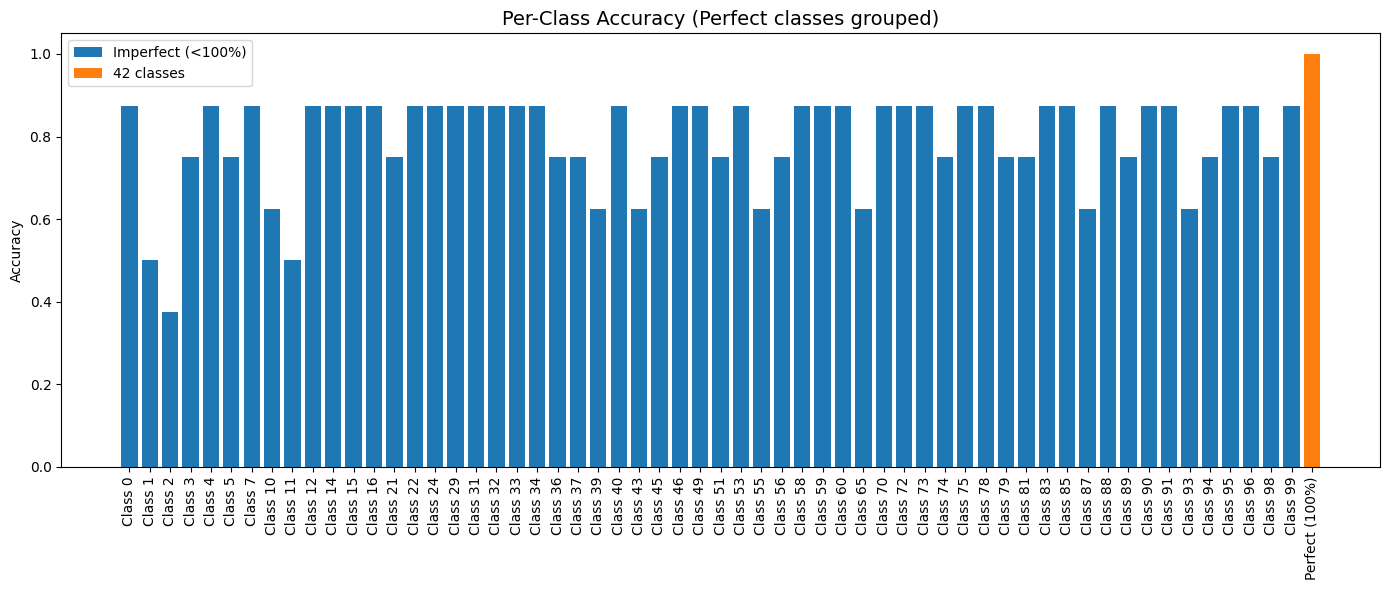

              precision    recall  f1-score   support

           0   1.000000  0.875000  0.933333         8
           1   0.800000  0.500000  0.615385         8
           2   1.000000  0.375000  0.545455         8
           3   0.666667  0.750000  0.705882         8
           4   1.000000  0.875000  0.933333         8
           5   0.857143  0.750000  0.800000         8
           6   0.888889  1.000000  0.941176         8
           7   0.777778  0.875000  0.823529         8
           8   1.000000  1.000000  1.000000         8
           9   0.888889  1.000000  0.941176         8
          10   1.000000  0.625000  0.769231         8
          11   0.800000  0.500000  0.615385         8
          12   0.875000  0.875000  0.875000         8
          13   0.888889  1.000000  0.941176         8
          14   0.700000  0.875000  0.777778         8
          15   1.000000  0.875000  0.933333         8
          16   1.000000  0.875000  0.933333         8
          17   1.000000  1.

In [15]:
checkpoints = ['checkpoint_t_10.pth']
path_dir = 'out-checkpoints/WLASL100'
for ckp in checkpoints:
    path = f'{path_dir}/{ckp}'
    if not os.path.exists(path):
        continue
    model=torch.load(path, weights_only=False)

    print(f'=== {ckp} ===')
    ConfusionMatrix_zzz(model, eval_loader, device)

=== checkpoint_t_10.pth ===
Accuracy: 0.87875
Accuracy Top 5: 0.935


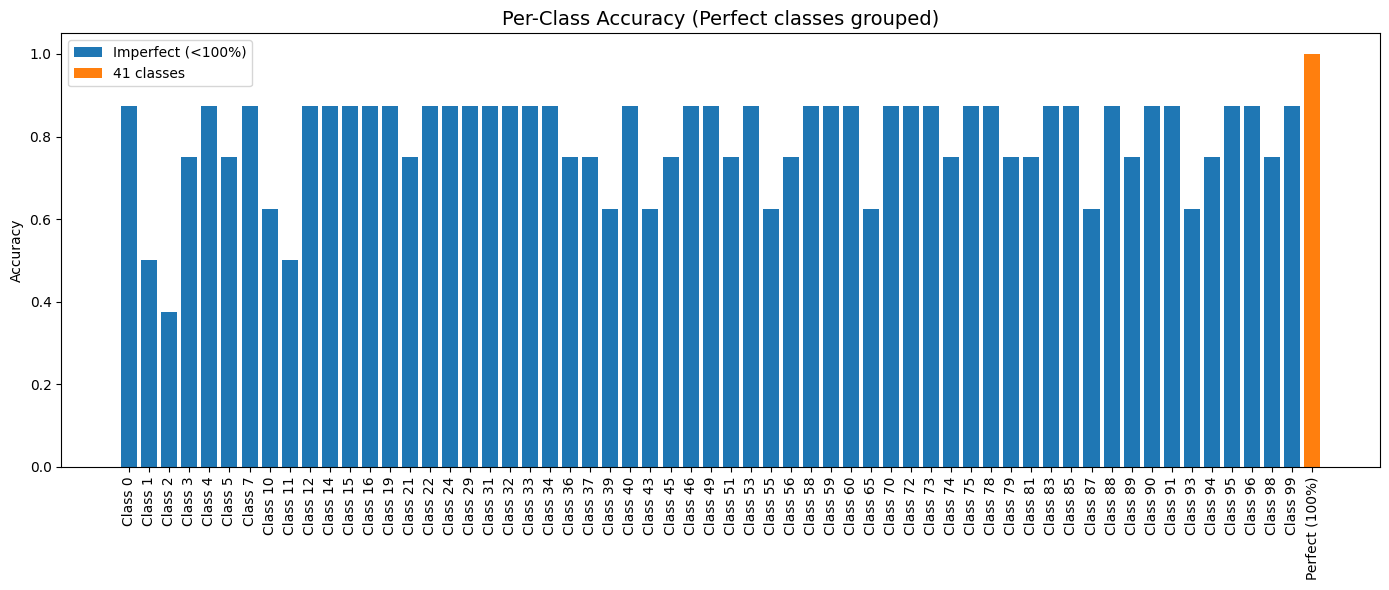

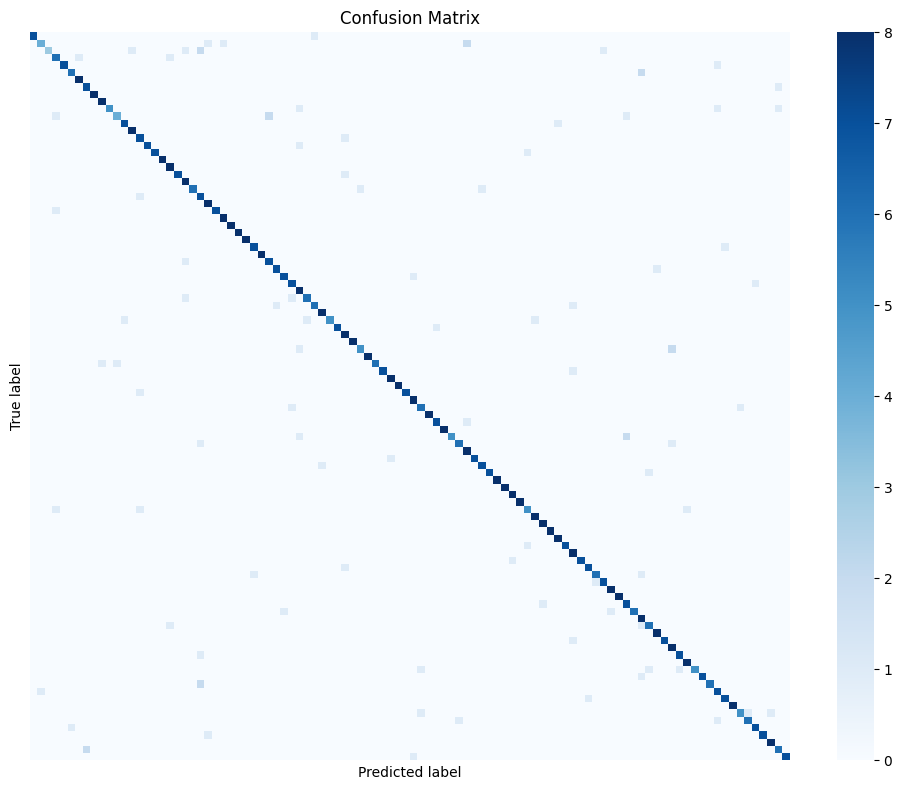

              precision    recall  f1-score   support

           0   1.000000  0.875000  0.933333         8
           1   0.800000  0.500000  0.615385         8
           2   1.000000  0.375000  0.545455         8
           3   0.666667  0.750000  0.705882         8
           4   1.000000  0.875000  0.933333         8
           5   0.857143  0.750000  0.800000         8
           6   0.888889  1.000000  0.941176         8
           7   0.777778  0.875000  0.823529         8
           8   1.000000  1.000000  1.000000         8
           9   0.888889  1.000000  0.941176         8
          10   1.000000  0.625000  0.769231         8
          11   0.800000  0.500000  0.615385         8
          12   0.875000  0.875000  0.875000         8
          13   0.888889  1.000000  0.941176         8
          14   0.700000  0.875000  0.777778         8
          15   1.000000  0.875000  0.933333         8
          16   1.000000  0.875000  0.933333         8
          17   1.000000  1.

In [27]:
checkpoints = ['checkpoint_t_10.pth']
path_dir = 'out-checkpoints/WLASL100'
for ckp in checkpoints:
    path = f'{path_dir}/{ckp}'
    if not os.path.exists(path):
        continue
    model=torch.load(path, weights_only=False)

    print(f'=== {ckp} ===')
    ConfusionMatrix_zzz(model, eval_loader, device)